In [41]:
# Turtle Trading Strategy Implementation
"""
# Turtle Trading Strategy for Stock Analysis

This notebook implements a simplified version of the famous Turtle Trading strategy
developed in the 1980s. The strategy works by:

1. Identifying breakouts from recent highs (selling signal) or lows (buying signal)
2. Using a rolling window of historical prices to determine entry and exit points
3. Generating buy signals (1) when price falls below recent lows (mean reversion)
4. Generating sell signals (-1) when price rises above recent highs (profit taking)

This implementation includes:
- Signal generation based on price breakouts
- Visualization of trading signals on price charts
- Performance metrics calculation (returns, drawdowns)
- Position sizing based on volatility
- Trailing stop-loss mechanisms
"""

# Import necessary libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
sns.set()  # Set seaborn styling for plots


In [42]:
# Load and prepare stock data
ticker = "GOOGL"  # Stock ticker symbol
file_location = f"../data/{ticker}.csv"

# Read the CSV file containing historical stock data
df = pd.read_csv(file_location)

# Convert date column to datetime for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()  # Display first few rows of the data


,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2017-05-31,GOOGL,49.119663,49.742187,48.850450,49.573495,34482000
2017-06-01,GOOGL,49.179379,49.420725,48.831042,49.312242,26128000
2017-06-02,GOOGL,49.569016,49.586931,49.118669,49.194308,34710000
2017-06-05,GOOGL,49.955162,50.130323,49.535667,49.657088,27578000
2017-06-06,GOOGL,49.596878,50.190540,49.503327,49.926802,31042000


In [43]:
# Implement the Turtle Trading strategy

# Calculate the size of the rolling window (10% of the dataset)
count = int(np.ceil(len(df) * 0.1))

# Create a new DataFrame to store signals and trend data
signals = pd.DataFrame(index=df.index)
signals['signal'] = 0.0  # Initialize all signals to neutral (0)
signals['trend'] = df['Close']  # Use closing price as the trend indicator

# Calculate rolling maximum and minimum values over the specified window
# shift(1) ensures we're not using future data in our calculations (avoiding lookahead bias)
signals['RollingMax'] = (signals.trend.shift(1).rolling(count).max())
signals['RollingMin'] = (signals.trend.shift(1).rolling(count).min())

# Generate trading signals:
# -1 (sell) when price exceeds the rolling maximum (breakout to the upside)
signals.loc[signals['RollingMax'] < signals.trend, 'signal'] = -1
# 1 (buy) when price falls below the rolling minimum (breakout to the downside)
signals.loc[signals['RollingMin'] > signals.trend, 'signal'] = 1

# Display the resulting signals DataFrame
signals.head()


,signal,trend,RollingMax,RollingMin
Date,,,,
2017-05-31,0.0,49.119663,NaN,NaN
2017-06-01,0.0,49.179379,NaN,NaN
2017-06-02,0.0,49.569016,NaN,NaN
2017-06-05,0.0,49.955162,NaN,NaN
2017-06-06,0.0,49.596878,NaN,NaN


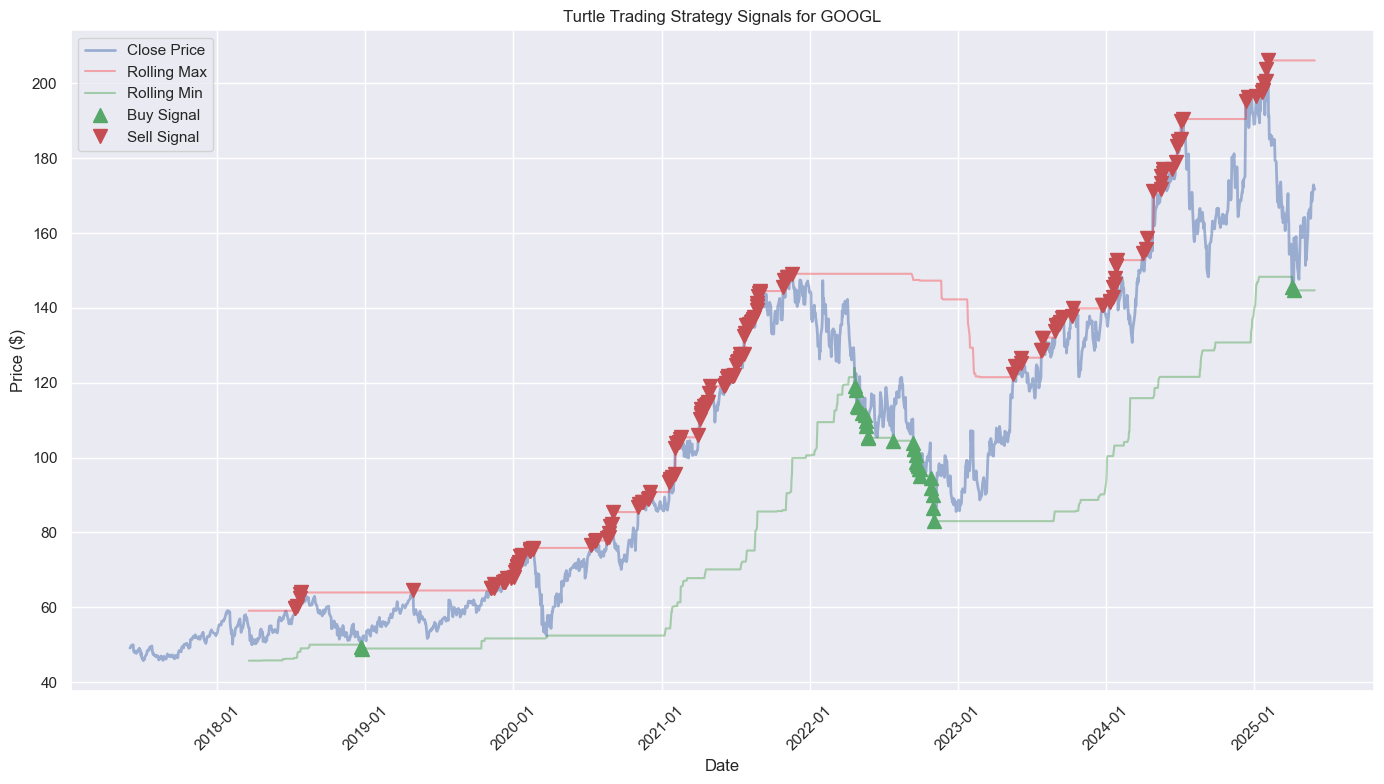

In [44]:
# 1. Visualization of the signals on a price chart

def plot_signals(signals):
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot the closing price
    ax.plot(signals.index, signals['trend'], label='Close Price', alpha=0.5, linewidth=2)

    # Plot the rolling max and min
    ax.plot(signals.index, signals['RollingMax'], label='Rolling Max', color='red', alpha=0.3)
    ax.plot(signals.index, signals['RollingMin'], label='Rolling Min', color='green', alpha=0.3)

    # Plot buy signals
    ax.plot(signals.loc[signals.signal == 1.0].index,
            signals.trend[signals.signal == 1.0],
            '^', markersize=10, color='g', label='Buy Signal')

    # Plot sell signals
    ax.plot(signals.loc[signals.signal == -1.0].index,
            signals.trend[signals.signal == -1.0],
            'v', markersize=10, color='r', label='Sell Signal')

    # Set labels and title
    ax.set_title(f'Turtle Trading Strategy Signals for {ticker}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='best')
    ax.grid(True)

    # Format the date axis
    date_format = DateFormatter("%Y-%m")
    ax.xaxis.set_major_formatter(date_format)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Visualize the signals
plot_signals(signals)


Performance Metrics for GOOGL Turtle Trading Strategy:
Total Return: 2.66%
Annualized Return: 0.33%
Sharpe Ratio: 0.33
Maximum Drawdown: 1.56%


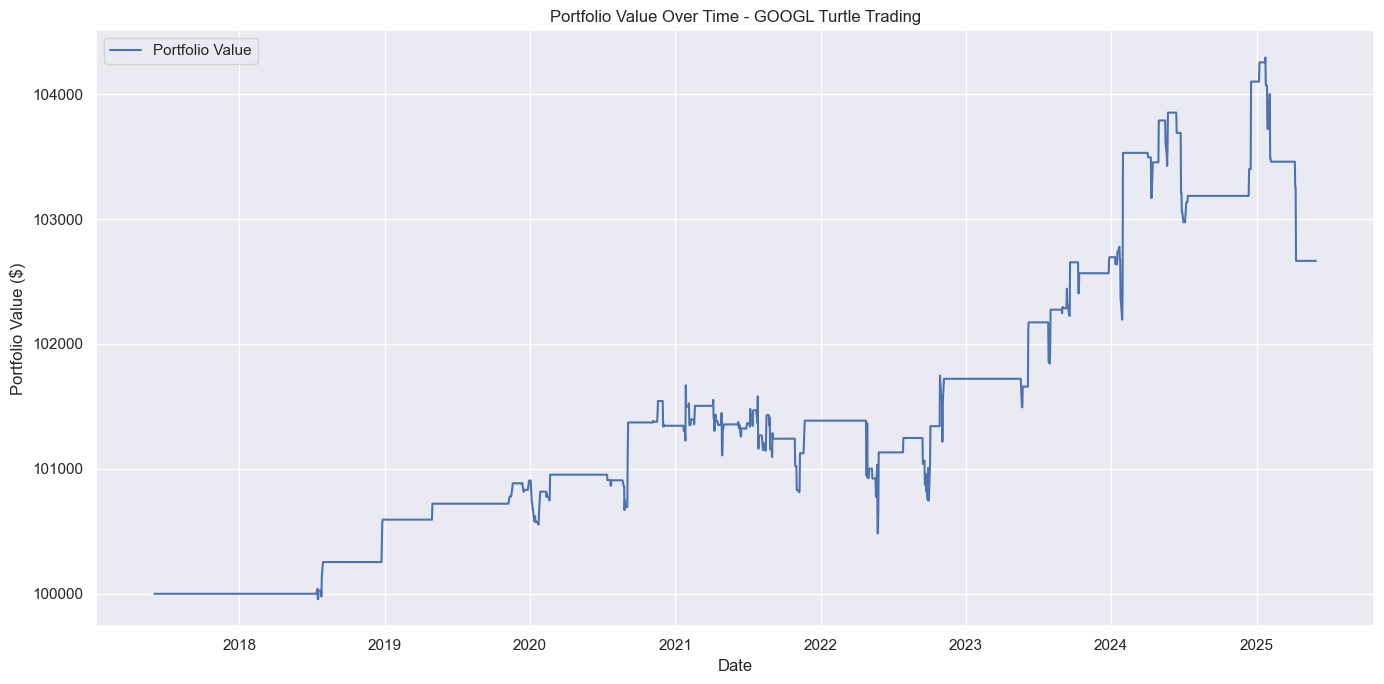

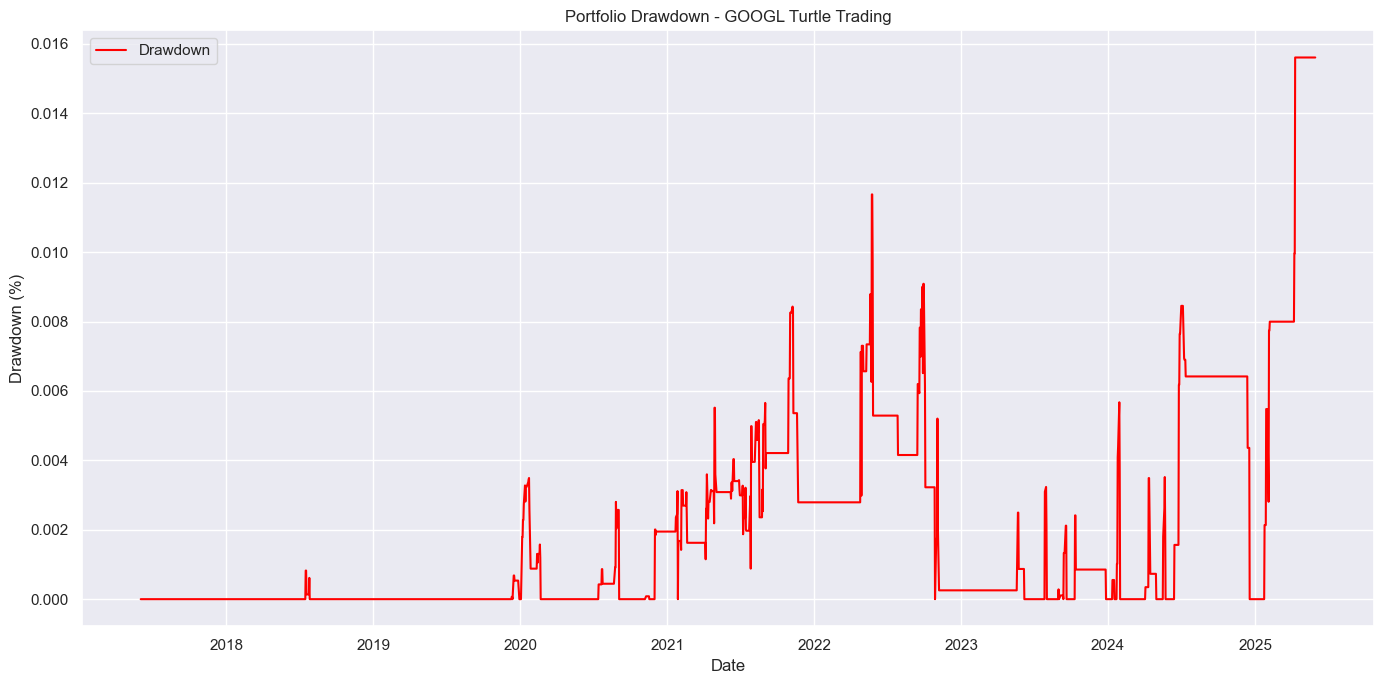

In [45]:
# 2. Performance metrics (returns, drawdowns, etc.)

def calculate_performance(signals, initial_capital=100000.0):
    """
    Calculate performance metrics for the strategy.
    """
    # Create a new DataFrame for positions and portfolio value
    positions = pd.DataFrame(index=signals.index)
    portfolio = pd.DataFrame(index=signals.index)

    # Store positions and calculate daily holdings value
    positions['GOOGL'] = 100 * signals['signal'].shift(1)  # Using fixed position size for now
    #positions['GOOGL'].fillna(0, inplace=True)  # Fill NaN values with 0
    positions['GOOGL'] = positions['GOOGL'].fillna(0)

    # Calculate daily holdings value and cash positions
    portfolio['holdings'] = positions.mul(signals['trend'], axis=0)
    portfolio['cash'] = initial_capital - (positions.diff().mul(signals['trend'], axis=0)).cumsum()

    # Calculate total portfolio value and returns
    portfolio['total'] = portfolio['holdings'] + portfolio['cash']
    portfolio['returns'] = portfolio['total'].pct_change()

    # Calculate drawdown
    portfolio['cumulative_returns'] = (1 + portfolio['returns']).cumprod()
    portfolio['cumulative_max'] = portfolio['cumulative_returns'].cummax()
    portfolio['drawdown'] = (portfolio['cumulative_max'] - portfolio['cumulative_returns']) / portfolio['cumulative_max']

    # Performance metrics
    total_return = portfolio['cumulative_returns'].iloc[-1] - 1.0
    annual_return = (1 + total_return) ** (252 / len(portfolio)) - 1  # Assuming 252 trading days per year
    sharpe_ratio = np.sqrt(252) * portfolio['returns'].mean() / portfolio['returns'].std()
    max_drawdown = portfolio['drawdown'].max()

    print(f"Performance Metrics for {ticker} Turtle Trading Strategy:")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return: {annual_return:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2%}")

    return portfolio

# Calculate performance metrics
portfolio = calculate_performance(signals)

# Plot the portfolio value over time
plt.figure(figsize=(14, 7))
plt.plot(portfolio['total'], label='Portfolio Value')
plt.title(f'Portfolio Value Over Time - {ticker} Turtle Trading')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot drawdowns
plt.figure(figsize=(14, 7))
plt.plot(portfolio['drawdown'], label='Drawdown', color='red')
plt.title(f'Portfolio Drawdown - {ticker} Turtle Trading')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [46]:
# 3. Position sizing based on volatility (ATR - Average True Range)

def add_position_sizing(signals, risk_percent=0.01):
    """
    Add position sizing based on volatility using ATR (Average True Range).

    Parameters:
    - signals: DataFrame containing signals
    - risk_percent: Percentage of portfolio to risk per trade (default: 1%)

    Returns:
    - Updated signals DataFrame with position sizes
    """

    # Calculate True Range (TR)
    signals['high'] = df['High']
    signals['low'] = df['Low']
    signals['close_prev'] = signals['trend'].shift(1)

    # True Range calculation
    signals['TR1'] = abs(signals['high'] - signals['low'])
    signals['TR2'] = abs(signals['high'] - signals['close_prev'])
    signals['TR3'] = abs(signals['low'] - signals['close_prev'])
    signals['TR'] = signals[['TR1', 'TR2', 'TR3']].max(axis=1)

    # Calculate ATR (20-day Average True Range)
    signals['ATR'] = signals['TR'].rolling(window=20).mean()

    # Calculate position size (N shares)
    # Formula: Position Size = (Account Risk) / (Trade Risk per Share)
    # Where Account Risk = Portfolio Value * Risk Percent
    # And Trade Risk per Share = ATR * 2 (using 2 ATR as stop loss distance)
    portfolio_value = 100000  # Initial portfolio value
    account_risk = portfolio_value * risk_percent
    signals['position_size'] = 0

    for i in range(20, len(signals)):
        if signals['ATR'].iloc[i] > 0:
            trade_risk_per_share = signals['ATR'].iloc[i] * 2
            if 'position_size' in signals.columns:
                signals['position_size'] = signals['position_size'].astype(float)
            signals.loc[signals.index[i], 'position_size'] = account_risk / trade_risk_per_share

    # Ensure position size is proportional to signal
    signals['position_size'] = signals['position_size'] * signals['signal']

    return signals


# Add position sizing to signals
signals = add_position_sizing(signals)

# Display the updated signals DataFrame
signals[['trend', 'signal', 'ATR', 'position_size']].tail(10)


,trend,signal,ATR,position_size
Date,,,,
2025-05-16,166.190002,0.0,5.217500,0.0
2025-05-19,166.539993,0.0,5.085500,0.0
2025-05-20,163.979996,0.0,5.139500,0.0
2025-05-21,168.559998,0.0,5.315501,0.0
2025-05-22,170.869995,0.0,5.514001,0.0
2025-05-23,168.470001,0.0,5.322001,0.0
2025-05-27,172.899994,0.0,5.329501,0.0
2025-05-28,172.360001,0.0,5.336501,0.0
2025-05-29,171.860001,0.0,5.288000,0.0


In [53]:
# 4. Trailing stop-loss mechanisms

def apply_trailing_stop(signals, atr_multiple=2):
    """
    Apply trailing stop-loss mechanism to the trading strategy.

    Parameters:
    - signals: DataFrame containing signals and position sizes
    - atr_multiple: Multiple of ATR to use for stop-loss distance (default: 2)

    Returns:
    - Updated signals DataFrame with stop-loss levels
    """
    # Initialize columns for stop-loss levels and updated signals
    signals['stop_loss'] = np.nan
    signals['updated_signal'] = signals['signal'].copy()

    # Iterate through the DataFrame
    current_position = 0
    stop_level = np.nan

    for i in range(20, len(signals)):  # Start from 20 since ATR needs at least 20 days
        date = signals.index[i]
        price = signals.loc[date, 'trend']
        atr = signals.loc[date, 'ATR']
        signal = signals.loc[date, 'signal']

        # Update stop-loss level when a new position is taken
        if (current_position == 0 and signal != 0) or (current_position != 0 and signal != 0 and signal != current_position):
            current_position = signal

            if signal == 1:  # Long position
                stop_level = price - (atr * atr_multiple)
            elif signal == -1:  # Short position
                stop_level = price + (atr * atr_multiple)

        # Update trailing stop for existing positions
        if current_position == 1:  # Long position
            # Raise stop-loss level as price increases
            if price - (atr * atr_multiple) > stop_level:
                stop_level = price - (atr * atr_multiple)

            # Check if stop-loss is triggered
            if price < stop_level:
                signals.loc[date, 'updated_signal'] = 0
                current_position = 0
                stop_level = np.nan

        elif current_position == -1:  # Short position
            # Lower stop-loss level as price decreases
            if price + (atr * atr_multiple) < stop_level:
                stop_level = price + (atr * atr_multiple)

            # Check if stop-loss is triggered
            if price > stop_level:
                signals.loc[date, 'updated_signal'] = 0
                current_position = 0
                stop_level = np.nan

        # Record the current stop-loss level
        signals.loc[date, 'stop_loss'] = stop_level

    return signals

# Apply trailing stop-loss mechanism
signals = apply_trailing_stop(signals)

# Display the updated signals DataFrame
signals[['trend', 'signal', 'updated_signal', 'ATR', 'stop_loss']].tail(10)


,trend,signal,updated_signal,ATR,stop_loss
Date,,,,,
2025-05-16,166.190002,0.0,0.0,5.217500,NaN
2025-05-19,166.539993,0.0,0.0,5.085500,NaN
2025-05-20,163.979996,0.0,0.0,5.139500,NaN
2025-05-21,168.559998,0.0,0.0,5.315501,NaN
2025-05-22,170.869995,0.0,0.0,5.514001,NaN
2025-05-23,168.470001,0.0,0.0,5.322001,NaN
2025-05-27,172.899994,0.0,0.0,5.329501,NaN
2025-05-28,172.360001,0.0,0.0,5.336501,NaN
2025-05-29,171.860001,0.0,0.0,5.288000,NaN


Let me break down what each column means:

* trend: This is the stock's closing price for the given date. It ranges from $163.98 to $172.90 in your example.

* signal: This shows the trading signal. Values are:

    * 0 = no action (neutral)
    * 1 = buy signal
    * -1 = sell signal
In your example, all values are 0, meaning no trade signals were generated during this period.

* ATR: Average True Range, a measure of price volatility over the specified period (typically 20 days). Your values range from about 5.08 to 5.53.

* position_size: The calculated position size based on the ATR and risk parameters. This value represents how many shares to buy or sell when a signal is generated.

When you see zeros for the signal, it means that:

The price hasn't broken above the rolling maximum (which would generate a sell signal of -1)
The price hasn't broken below the rolling minimum (which would generate a buy signal of 1)
In this specific period (May 16-30, 2025), the price is moving within its normal range as defined by the strategy's parameters, so no trading action is recommended. This is normal behavior for the Turtle Trading strategy, which only generates signals during significant breakouts from recent price ranges.

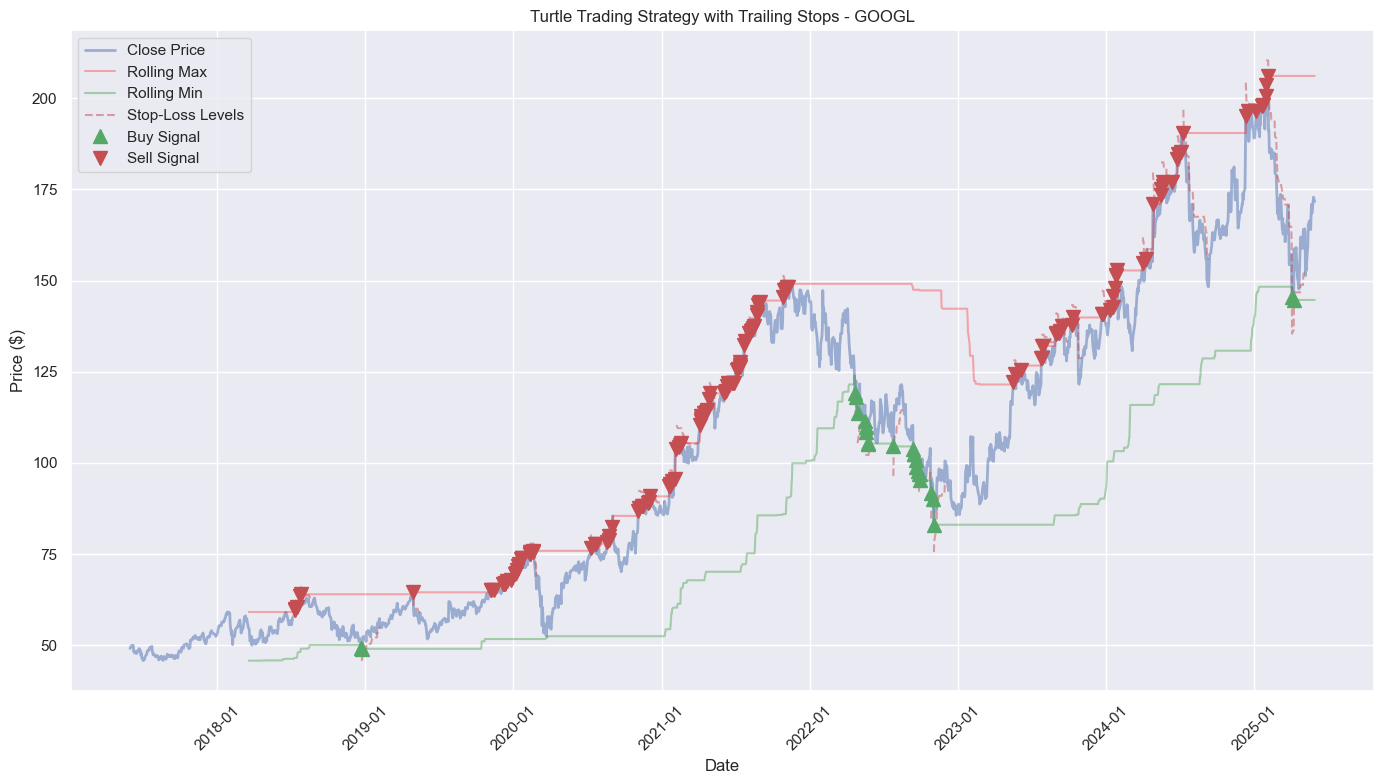

In [48]:
# Visualize the strategy with trailing stops

def plot_strategy_with_stops(signals):
    """
    Plot the strategy including trailing stop-loss levels.
    """
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot the closing price
    ax.plot(signals.index, signals['trend'], label='Close Price', alpha=0.5, linewidth=2)

    # Plot the rolling max and min
    ax.plot(signals.index, signals['RollingMax'], label='Rolling Max', color='red', alpha=0.3)
    ax.plot(signals.index, signals['RollingMin'], label='Rolling Min', color='green', alpha=0.3)

    # Plot stop-loss levels
    ax.plot(signals.index, signals['stop_loss'], 'r--', alpha=0.5, label='Stop-Loss Levels')

    # Plot buy signals with updated signals
    buy_signals = signals.loc[signals.updated_signal == 1.0]
    ax.plot(buy_signals.index, buy_signals.trend,
            '^', markersize=10, color='g', label='Buy Signal')

    # Plot sell signals with updated signals
    sell_signals = signals.loc[signals.updated_signal == -1.0]
    ax.plot(sell_signals.index, sell_signals.trend,
            'v', markersize=10, color='r', label='Sell Signal')

    # Set labels and title
    ax.set_title(f'Turtle Trading Strategy with Trailing Stops - {ticker}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='best')
    ax.grid(True)

    # Format the date axis
    date_format = DateFormatter("%Y-%m")
    ax.xaxis.set_major_formatter(date_format)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Visualize the strategy with trailing stops
plot_strategy_with_stops(signals)


In [49]:
##%%
# Recalculate performance metrics with updated signals and position sizing

def calculate_advanced_performance(signals, initial_capital=100000.0):
    """
    Calculate performance metrics for the strategy with position sizing and trailing stops.
    """
    # Create a new DataFrame for positions and portfolio value
    positions = pd.DataFrame(index=signals.index)
    portfolio = pd.DataFrame(index=signals.index)
    
    # Use position sizes and updated signals for more realistic results
    positions['GOOGL'] = signals['position_size'].shift(1)  # Use position size based on ATR
    # positions['GOOGL'].fillna(0, inplace=True)  # Fill NaN values with 0
    positions['GOOGL'] = positions['GOOGL'].fillna(0)
    
    # Calculate daily holdings value and cash positions
    portfolio['holdings'] = positions.mul(signals['trend'], axis=0)
    portfolio['cash'] = initial_capital - (positions.diff().mul(signals['trend'], axis=0)).cumsum()
    
    # Calculate total portfolio value and returns
    portfolio['total'] = portfolio['holdings'] + portfolio['cash']
    portfolio['returns'] = portfolio['total'].pct_change()
    
    # Calculate drawdown
    portfolio['cumulative_returns'] = (1 + portfolio['returns']).cumprod()
    portfolio['cumulative_max'] = portfolio['cumulative_returns'].cummax()
    portfolio['drawdown'] = (portfolio['cumulative_max'] - portfolio['cumulative_returns']) / portfolio['cumulative_max']
    
    # Calculate additional performance metrics
    total_return = portfolio['cumulative_returns'].iloc[-1] - 1.0
    annual_return = (1 + total_return) ** (252 / len(portfolio)) - 1  # Assuming 252 trading days per year
    sharpe_ratio = np.sqrt(252) * portfolio['returns'].mean() / portfolio['returns'].std()
    max_drawdown = portfolio['drawdown'].max()
    
    # Calculate win rate and profit factor
    trades = signals['updated_signal'].diff().fillna(0)
    winning_trades = portfolio['returns'][trades != 0]
    win_rate = len(winning_trades[winning_trades > 0]) / len(winning_trades) if len(winning_trades) > 0 else 0
    
    # Calculate profit factor (sum of profits / sum of losses)
    profits = winning_trades[winning_trades > 0].sum()
    losses = abs(winning_trades[winning_trades < 0].sum())
    profit_factor = profits / losses if losses != 0 else float('inf')
    
    print(f"Advanced Performance Metrics for {ticker} Turtle Trading Strategy:")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return: {annual_return:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2%}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Profit Factor: {profit_factor:.2f}")
    
    return portfolio

# Calculate advanced performance metrics
advanced_portfolio = calculate_advanced_performance(signals)



Advanced Performance Metrics for GOOGL Turtle Trading Strategy:
Total Return: 7.18%
Annualized Return: 0.87%
Sharpe Ratio: 0.47
Maximum Drawdown: 2.15%
Win Rate: 27.55%
Profit Factor: 0.84


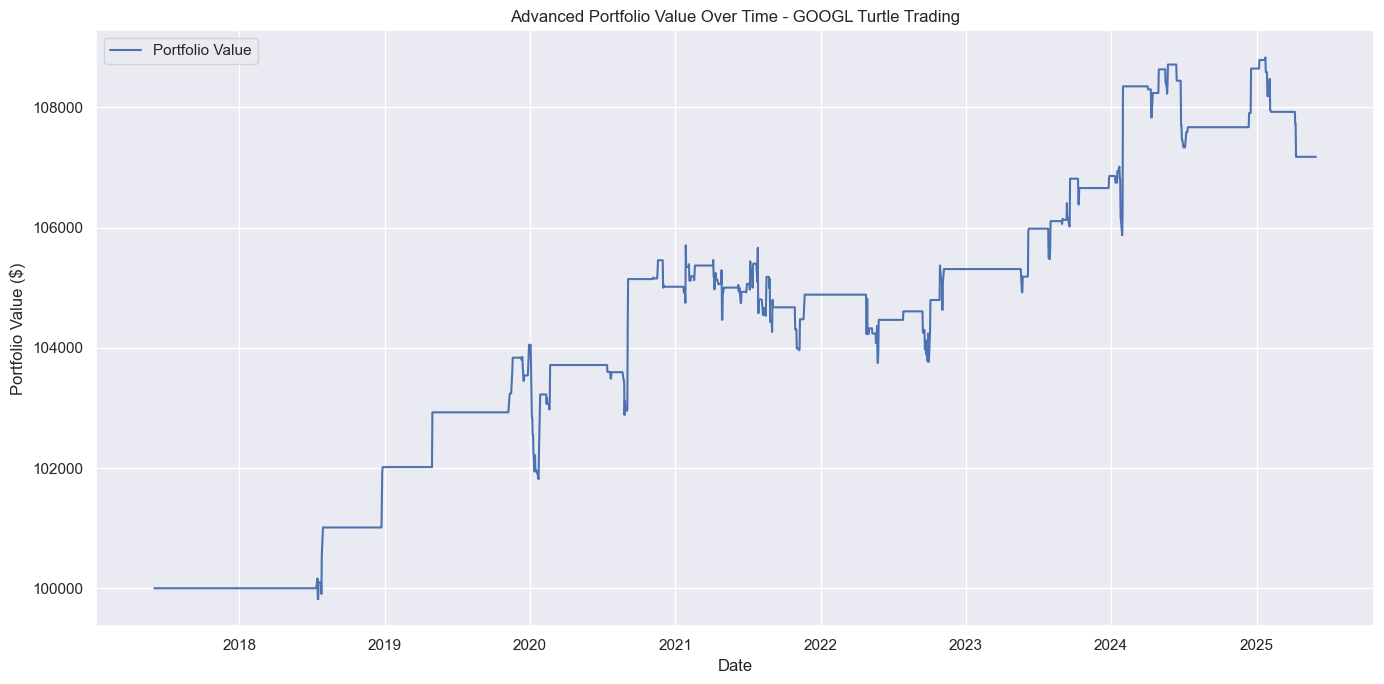

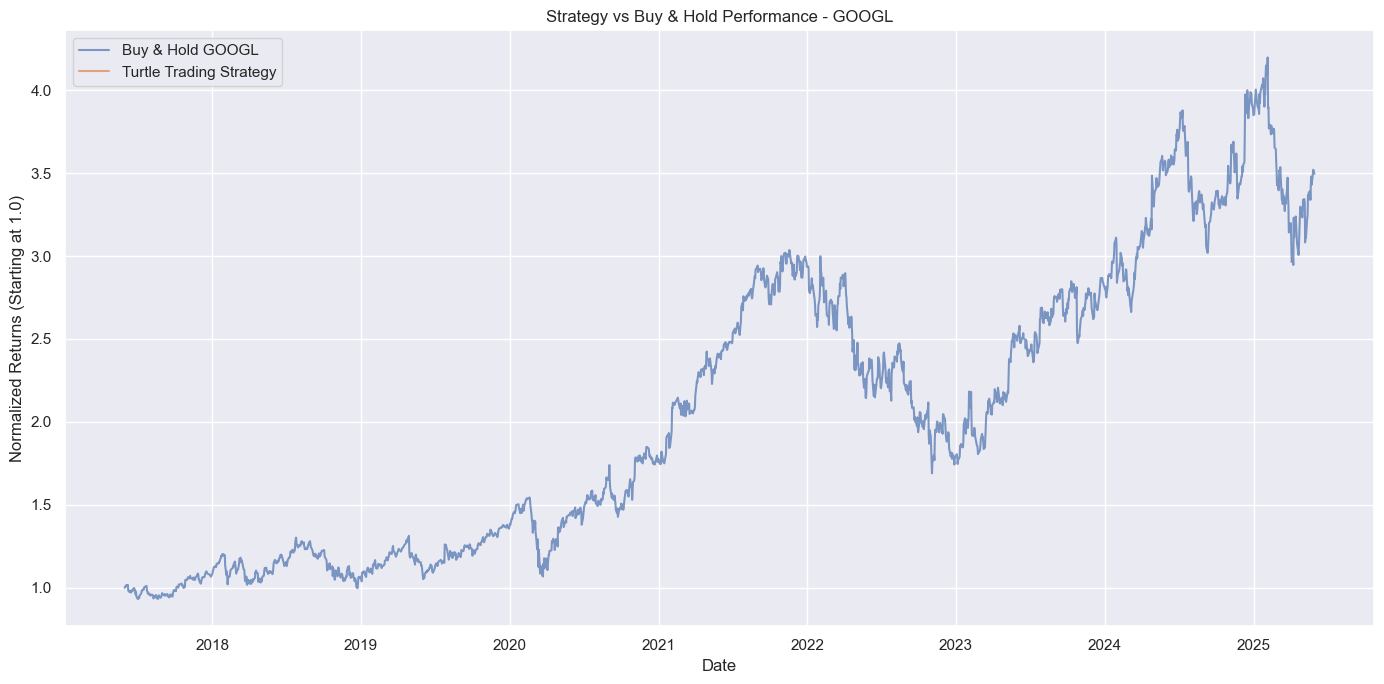

In [50]:
##%%
# Plot the advanced portfolio performance

plt.figure(figsize=(14, 7))
plt.plot(advanced_portfolio['total'], label='Portfolio Value')
plt.title(f'Advanced Portfolio Value Over Time - {ticker} Turtle Trading')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare strategy returns with buy-and-hold returns
plt.figure(figsize=(14, 7))
# Calculate buy and hold returns (normalized to start at 1.0)
buy_hold_returns = signals['trend'] / signals['trend'].iloc[0]

# Calculate strategy returns (normalized to start at 1.0)
strategy_returns = advanced_portfolio['total'] / advanced_portfolio['total'].iloc[0]

plt.plot(buy_hold_returns, label=f'Buy & Hold {ticker}', alpha=0.7)
plt.plot(strategy_returns, label='Turtle Trading Strategy', alpha=0.7)
plt.title(f'Strategy vs Buy & Hold Performance - {ticker}')
plt.xlabel('Date')
plt.ylabel('Normalized Returns (Starting at 1.0)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


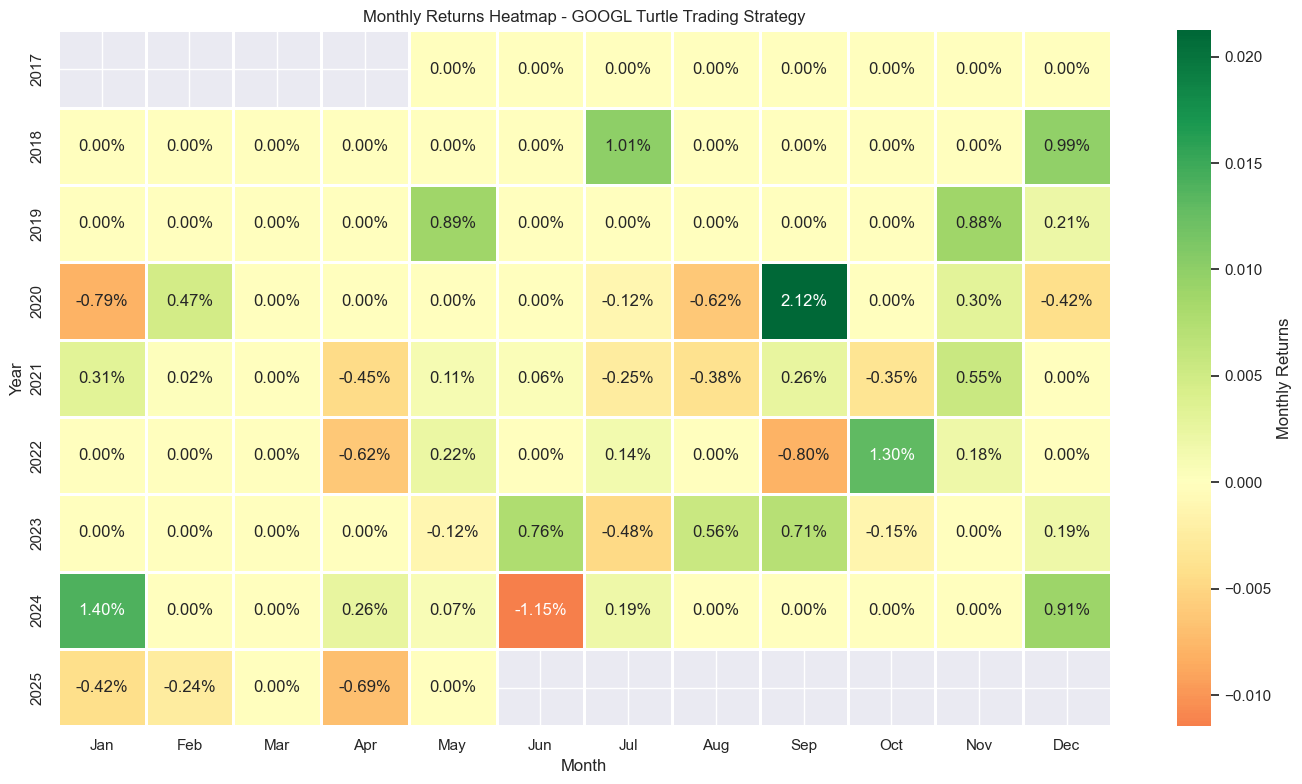

In [51]:
##%%
# Monthly returns heatmap

def plot_monthly_returns_heatmap(portfolio):
    """
    Plot a heatmap of monthly returns for the strategy.
    """
    # Resample returns to monthly frequency
    monthly_returns = portfolio['returns'].resample('ME').apply(
        lambda x: ((1 + x).prod() - 1)
    )
    
    # Create a pivot table with years as rows and months as columns
    monthly_returns_table = pd.DataFrame({
        'Year': monthly_returns.index.year,
        'Month': monthly_returns.index.month,
        'Returns': monthly_returns.values
    })
    
    # Use pivot_table instead of pivot
    pivot_table = monthly_returns_table.pivot_table(
        values='Returns', 
        index='Year', 
        columns='Month', 
        aggfunc='sum'  # Use sum since we should only have one value per year/month
    )
    
    # Plot the heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.2%', cmap='RdYlGn', center=0,
                linewidths=1, cbar_kws={'label': 'Monthly Returns'})
    
    plt.title(f'Monthly Returns Heatmap - {ticker} Turtle Trading Strategy')
    plt.xlabel('Month')
    plt.ylabel('Year')
    
    # Set month names as x-axis labels
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    # Only add month names if we have all 12 months in the data
    if len(pivot_table.columns) == 12:
        plt.xticks(np.arange(12) + 0.5, month_names)
    else:
        # Otherwise, use the existing column labels
        plt.xticks(np.arange(len(pivot_table.columns)) + 0.5, pivot_table.columns)
    
    plt.tight_layout()
    plt.show()

# Plot monthly returns heatmap
plot_monthly_returns_heatmap(advanced_portfolio)


##%%
# Summary and conclusion

# Turtle Trading Strategy Summary

This notebook has implemented a complete Turtle Trading strategy with the following components:

1. Signal Generation: Using rolling max/min to identify potential entry and exit points
2. Visualization: Charts showing price action with buy/sell signals and stop-loss levels
3. Position Sizing: Implementing ATR-based position sizing to manage risk effectively
4. Risk Management: Adding trailing stop-loss mechanisms to protect profits
5. Performance Analysis: Comprehensive metrics including returns, drawdowns, win rate, and profit factor

## Key Observations:

- The strategy attempts to capture mean reversion moves in the stock
- Position sizing adjusts exposure based on market volatility
- Trailing stops help to lock in profits and limit losses
- Performance metrics provide insight into the strategy's effectiveness compared to buy-and-hold

## Potential Improvements:

- Test different lookback periods for rolling max/min calculations
- Implement filters to avoid trading in choppy or sideways markets
- Add additional technical indicators to confirm signals
- Explore portfolio implementation across multiple stocks
- Incorporate transaction costs and slippage for more realistic results

##%%